## Demo for modelling single-channel PSF from bead data

#### Setup environment

In [1]:
import sys
sys.path.append("..")
from psflearning.psflearninglib import psflearninglib
from psflearning import io
from psflearning.makeplots import *
import tensorflow as tf
#main_data_dir = io.param.load('datapath.yaml').main_data_dir
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Running on GPU')
except:
    print('Running on CPU')

Running on GPU


#### Create psflearning object and load the config file
$\small\color{skyblue}{\mathrm{basefile}}$: config file with all parameters  
$\small\color{skyblue}{\mathrm{psftype}}$:  `'voxel', 'zernike'`  
$\small\color{skyblue}{\mathrm{sysfile}}$: config file with microscope specific parameters  
For advanced user, pass in base file only as below to interact with all parameters:   
```python
    L.param = io.param.combine('config_user')
```

In [2]:
L = psflearninglib()
L.param = io.param.combine('config_base',psftype='zernike',channeltype='2ch',sysfile='smart_tirf')


#### Edit user defined parameters

In [ ]:
L.param.datapath = r'C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\05-12-2025 2ch/'
L.param.keyword = 'bead2_100nm_darkred_mag50_widefield_PBS' # keyword for your data file
L.param.savename = L.param.datapath+'result/' + L.param.keyword
L.param.subfolder = '' # keyword for subfolder name if each data file is saved in a individual folder, set to '' if no subfolder
L.param.gain = 0.44
L.param.ccd_offset = 100
L.param.FOV.z_step = 1  
L.param.pixel_size.z = 0.1 # micron, equal to z_step*stepsize_of_the_data
L.param.roi.max_bead_number = 50 
L.param.roi.bead_radius = 0.0
L.param.ref_channel = 0 # choose the brighter channel as the reference channel, 0 or 1
L.param.batch_size = 30 # lower this number if out of memory
L.param.option.imaging.emission_wavelength = 0.68 # micron
L.param.varname = 'Main/data'


#### Start learning

In [4]:
images = L.load_data()

C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\05-12-2025 2ch\bead2_100nm_darkred_mag50_widefield_PBS2025-05-13_00-12-39.h5
C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\05-12-2025 2ch\bead2_100nm_darkred_mag50_widefield_PBS2025-05-13_00-16-22.h5
C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\05-12-2025 2ch\bead2_100nm_darkred_mag50_widefield_PBS2025-05-13_00-17-26.h5
C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\05-12-2025 2ch\bead2_100nm_darkred_mag50_widefield_PBS2025-05-13_00-19-36.h5
C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\05-12-2025 2ch\bead2_100nm_darkred_mag50_widefield_PBS2025-05-13_00-20-37.h5
C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\05-12-2025 2ch\bead2_100nm_darkred_mag50_widefield_PBS2025-05-13_00-21-47.h5
(2, 6, 21, 400, 800)


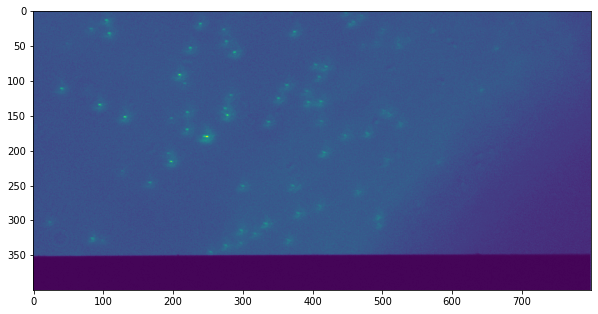

In [5]:
plt.figure(figsize=(10, 10))
plt.imshow(images[0][1][0])

In [6]:
L.getpsfclass()
L.param.roi.roi_size = [21,21]
L.param.roi.peak_height = 0.2
L.param.FOV.y_center = 150
L.param.FOV.x_center = 200
L.param.FOV.radius = 200
dataobj = L.prep_data(images)

rois shape channel 0: (50, 21, 21, 21)
rois shape channel 1: (50, 21, 21, 21)
rois shape channel 0: (47, 21, 21, 21)
rois shape channel 1: (47, 21, 21, 21)


In [7]:
#images = L.load_data()
#L.getpsfclass()
#dataobj = L.prep_data(images)
for k in range(0,1): # increase iteration number if necessary
    psfobj,fitter = L.learn_psf(dataobj,time=0)
resfile = L.save_result(psfobj,dataobj,fitter)

3/6: learning: 55/100 [00:08s]  6.83it/s, current loss: 3.02636, total time: 8.05s
3/6: learning: 54/100 [00:07s]  6.86it/s, current loss: 3.27759, total time: 15.92s
3/6: learning: 115/250 [00:35s]  3.22it/s, current loss: 5.74447, total time: 51.59s
4/6: calculating spline coefficients: 2/2 [00:01s]  1.12it/s total time: 53.37s
5/6: localization: 5/5 [00:05s]  1.10s/it total time: 58.87s


outlier id: [ 6 14 16 29]
rois shape channel 0: (43, 21, 21, 21)
rois shape channel 1: (43, 21, 21, 21)


3/6: learning: 131/250 [00:38s]  3.37it/s, current loss: 2.71569, total time: 97.78s
4/6: calculating spline coefficients: 2/2 [00:01s]  1.14it/s total time: 99.52s
5/6: localization: 5/5 [00:04s]  1.09it/s total time: 104.13s
6/6: saving results: [00:03s] total time: 107.71s


#### Show results

In [103]:
f,p = io.h5.load(resfile) # load result file

channel 0


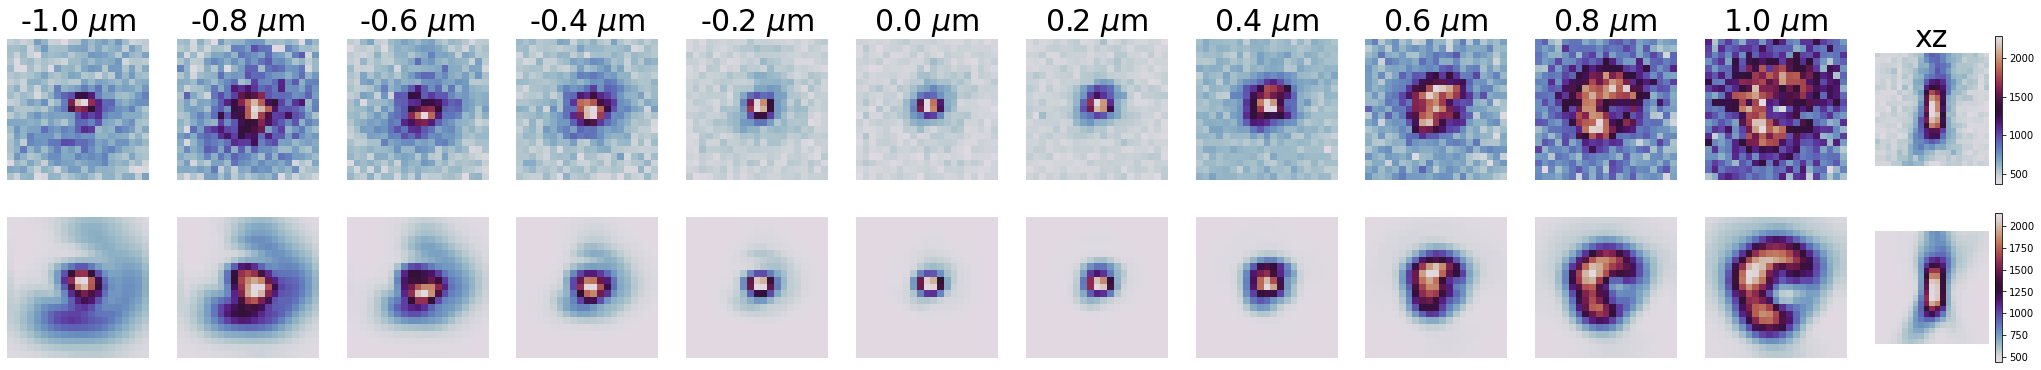

channel 1


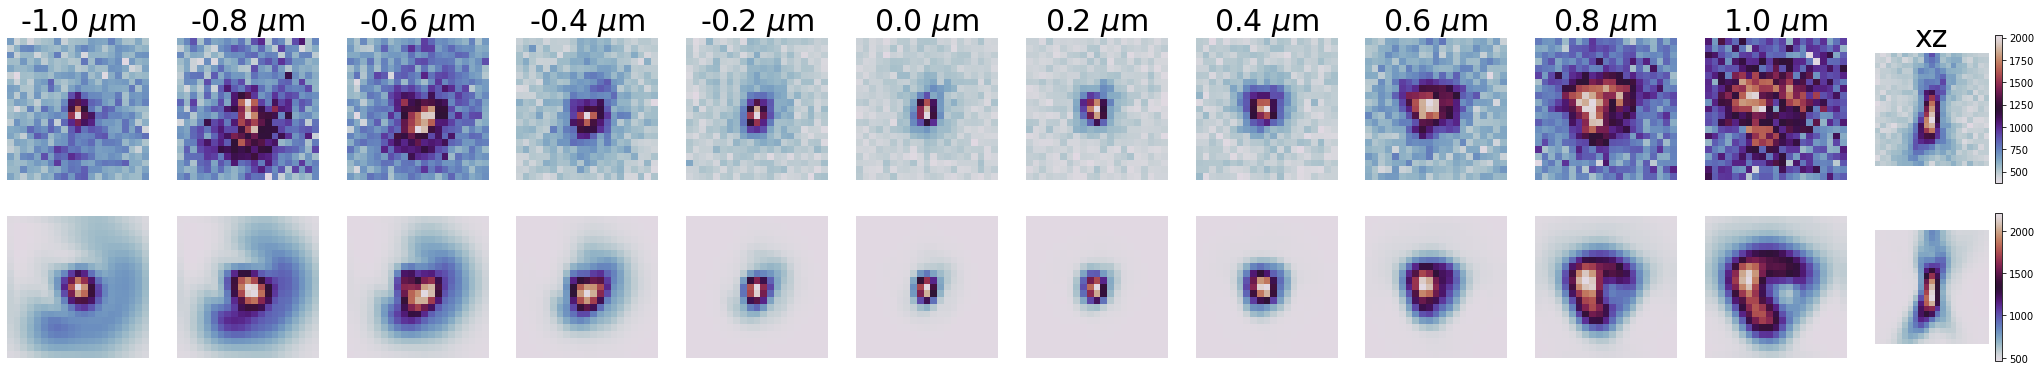

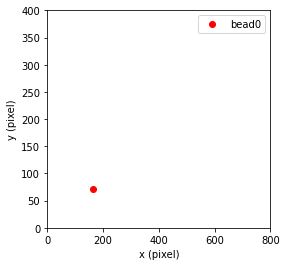

In [104]:
showpsfvsdata(f,p,index=0,step=2)

In [105]:
[f.res.channel0.sigma,f.res.channel1.sigma]

[array([0.6128, 0.6108], dtype=float32),
 array([0.6803, 0.6712], dtype=float32)]

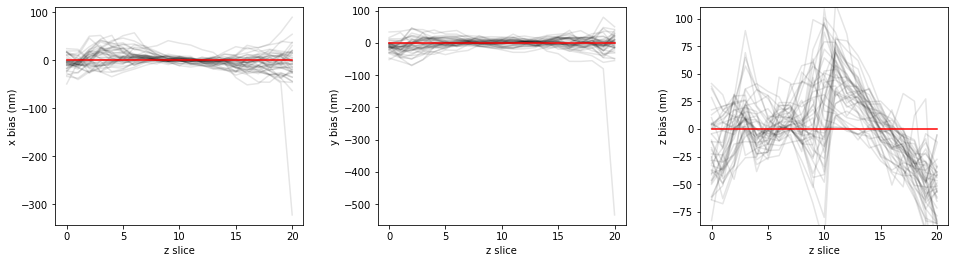

In [106]:
showlocalization(f,p)

#### Optional plots

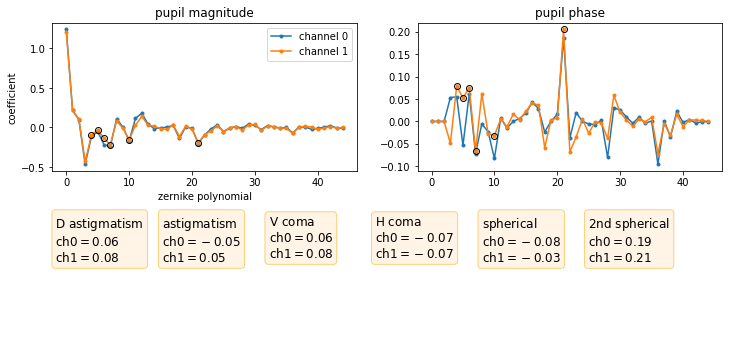

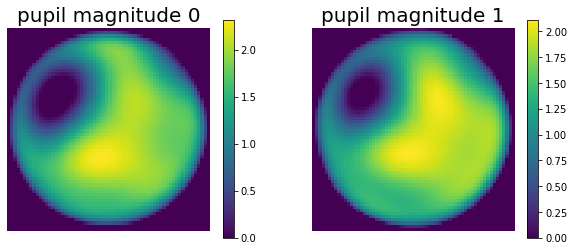

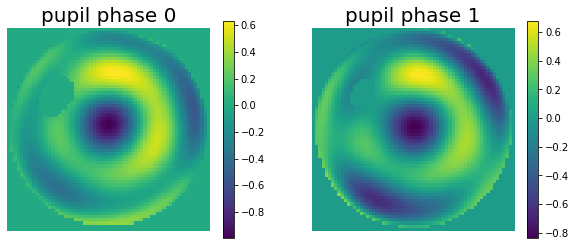

In [107]:
try:
    showzernike(f,p)
except:
    try: 
        showpupil(f,p)
    except:
        print('no pupil')

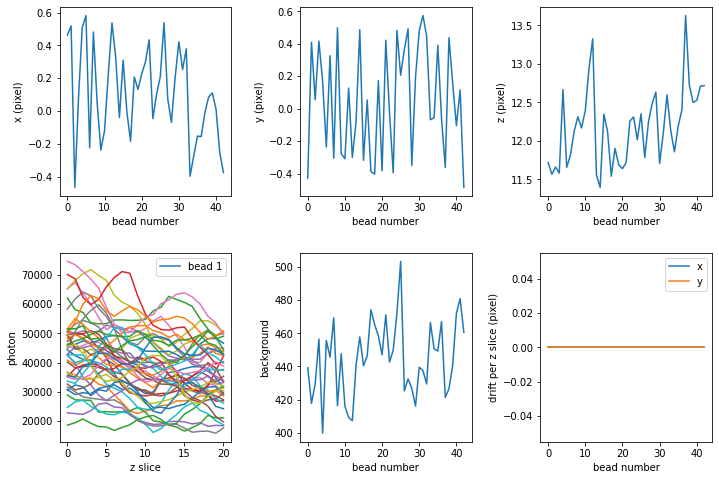

In [108]:
showlearnedparam(f,p)

[[ 1.0005 -0.0022 -0.    ]
 [ 0.0014  0.9998  0.    ]
 [ 2.0868 -0.8759  1.    ]]


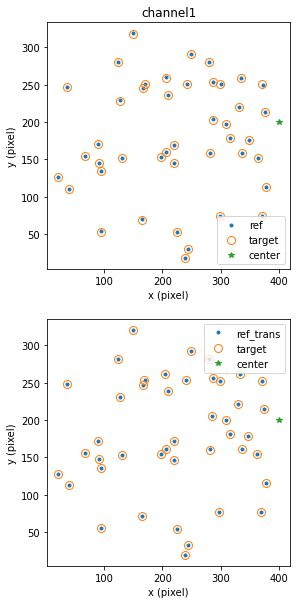

In [109]:
showtransform(f)
np.set_printoptions(precision=4,suppress=True)
print(f.res.T)

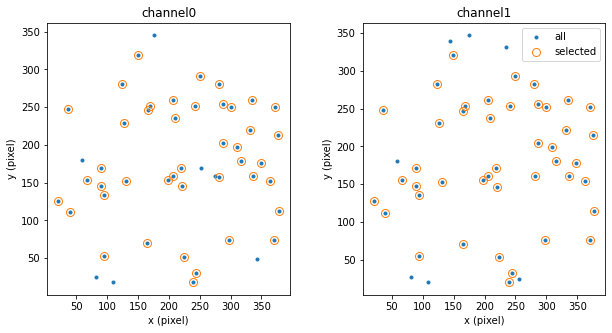

In [110]:
showcoord(f,p)

#### Ouput parameters

In [11]:
print('f:\n    ',list(f.keys()))
print(' locres:\n    ',list(f.locres.keys()))
print(' res:\n    ',list(f.res.keys()))
print(' rois:\n    ',list(f.rois.keys()))

f:
     ['locres', 'res', 'rois']
 locres:
     ['CRLB', 'LL', 'P', 'coeff', 'coeff_bead', 'coeff_reverse', 'loc']
 res:
     ['I_model', 'I_model_bead', 'I_model_reverse', 'apodization', 'bg', 'cor', 'cor_all', 'drift_rate', 'intensity', 'offset', 'pos', 'pupil', 'sigma', 'zernike_coeff', 'zernike_polynomial']
 rois:
     ['cor', 'fileID', 'image_size', 'psf_data', 'psf_fit']
